In [44]:
# =====================================
# STEP 1: Import Required Libraries
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

In [45]:
# =====================================
# STEP 2: Load Dataset
# =====================================

data = load_breast_cancer()

X = data.data      # Features
y = data.target    # Target (0 = malignant, 1 = benign)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [46]:
print("Shape of features:", X.shape)
print("Shape of target:", y.shape)

print("\nClass labels:")
print(data.target_names)

Shape of features: (569, 30)
Shape of target: (569,)

Class labels:
['malignant' 'benign']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
# Create scaler object
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use same scaler on test data
X_test_scaled = scaler.transform(X_test)

In [49]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy after scaling:", accuracy)

Accuracy after scaling: 0.9736842105263158


In [50]:
# =====================================
# STEP 8: Make Predictions
# =====================================

print("First 10 Predictions:", y_pred[:10])
print("Actual Values:", y_test[:10])

First 10 Predictions: [1 0 0 1 1 0 0 0 1 1]
Actual Values: [1 0 0 1 1 0 0 0 1 1]


In [51]:
# =====================================
# STEP 9: Evaluation
# =====================================

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Text(0, 0.5, 'True Label')

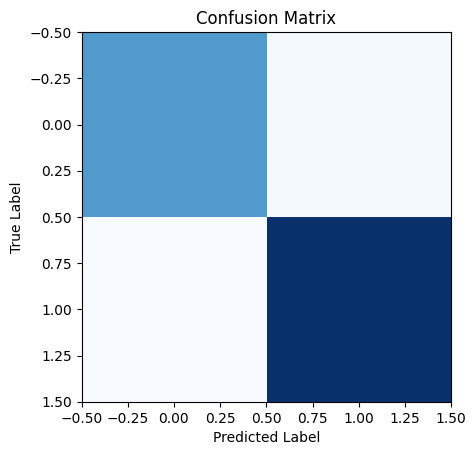

In [52]:
plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

In [53]:
# Get probability for class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

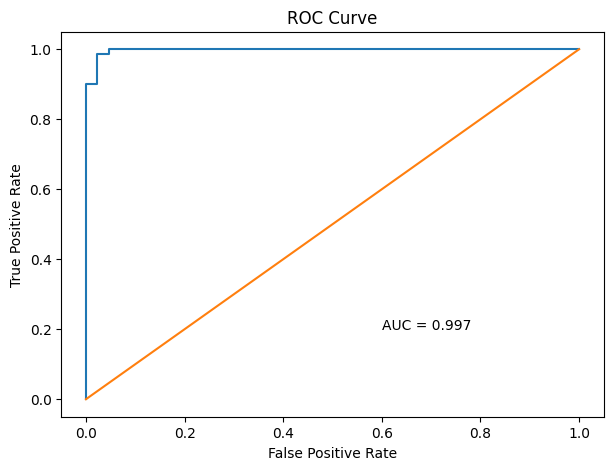

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])   # Diagonal reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.text(0.6, 0.2, "AUC = {:.3f}".format(auc_score))

plt.show()